# Praktikum 01: Citra sebagai Tensor, Ruang Warna & Ekualisasi Histogram

**Mata Kuliah Visi Komputer 2026 — Minggu 01**

Notebook ini siap dijalankan langsung di **Google Colab** (Runtime: CPU biasa sudah cukup, tidak perlu GPU).

## Alokasi Waktu: 50 Menit
- **Tugas 1 (15 menit):** Manipulasi Dimensi Tensor & Konversi Ruang Warna (BGR -> RGB -> HSV -> LAB)
- **Tugas 2 (20 menit):** Ekualisasi Histogram Manual dari Awal (Pure NumPy & PyTorch)
- **Tugas 3 (15 menit):** Pipeline Pemuatan Batch Tensor & Normalisasi Standar ImageNet

## Capaian Pembelajaran
1. Memahami representasi citra digital sebagai tensor multidimensi (`HWC` pada OpenCV vs `BCHW` pada PyTorch).
2. Melakukan segmentasi warna pada ruang warna HSV untuk mendeteksi objek di bawah pencahayaan dinamis.
3. Menurunkan dan mengimplementasikan transformasi Cumulative Distribution Function (CDF) untuk ekualisasi histogram.
4. Membangun pipeline normalisasi batch tensor di PyTorch.

## Setup
Colab biasanya sudah menyediakan `numpy`, `opencv-python-headless`, dan `torch` secara default. Cell di bawah memastikan semuanya tersedia (aman dijalankan meski sudah terpasang).

In [1]:
!pip install -q opencv-python-headless numpy torch torchvision

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

print("OpenCV :", cv2.__version__)
print("NumPy  :", np.__version__)
print("PyTorch:", torch.__version__)

OpenCV : 4.14.0
NumPy  : 2.1.3
PyTorch: 2.11.0+cpu


### Citra Uji (Sintetis)
Karena kita tidak mengunggah file, kita bangkitkan citra sintetis 3-kanal (kotak merah, lingkaran hijau, gradien biru) agar setiap orang mendapat hasil yang identik dan reproducible.

Shape (H, W, C): (720, 1280, 3), dtype: uint8


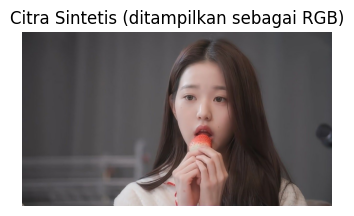

In [6]:
img_bgr = cv2.imread('wony.jpg')
print(f"Shape (H, W, C): {img_bgr.shape}, dtype: {img_bgr.dtype}")

plt.figure(figsize=(4, 3))
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.title("Citra Sintetis (ditampilkan sebagai RGB)")
plt.axis("off")
plt.show()

## Tugas 1 (15 menit): Manipulasi Dimensi Tensor & Konversi Ruang Warna

### Langkah 1: Slicing Tensor & Permutasi Kanal
- OpenCV membaca citra dalam format `(H, W, 3)` berurutan **BGR**.
- Konversi `BGR -> RGB` lalu ubah larik NumPy menjadi Tensor PyTorch dengan urutan dimensi `(H, W, C) -> (C, H, W)`, kemudian tambahkan dimensi batch `(1, C, H, W)`.

BGR shape : (720, 1280, 3)
HSV shape : (720, 1280, 3)
LAB shape : (720, 1280, 3)
Tensor CHW shape (sebelum batch): torch.Size([3, 720, 1280])
Tensor BCHW shape (setelah unsqueeze): torch.Size([1, 3, 720, 1280])


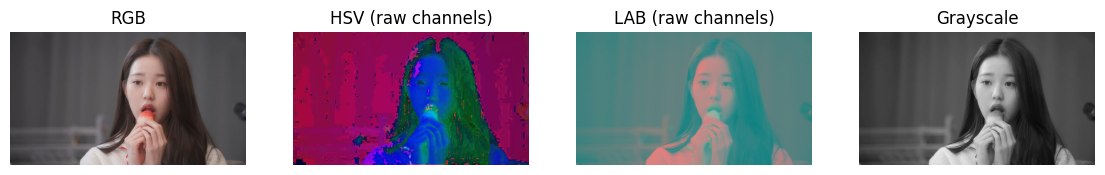

In [7]:
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)

# HWC uint8 -> CHW float32 [0, 1] -> tambah dimensi batch (1, C, H, W)
tensor_img = torch.from_numpy(img_rgb).permute(2, 0, 1).float() / 255.0
batch_tensor = tensor_img.unsqueeze(0)

print("BGR shape :", img_bgr.shape)
print("HSV shape :", img_hsv.shape)
print("LAB shape :", img_lab.shape)
print("Tensor CHW shape (sebelum batch):", tensor_img.shape)
print("Tensor BCHW shape (setelah unsqueeze):", batch_tensor.shape)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, im, title in zip(
    axes,
    [img_rgb, img_hsv, img_lab, cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)],
    ["RGB", "HSV (raw channels)", "LAB (raw channels)", "Grayscale"],
):
    ax.imshow(im, cmap="gray" if im.ndim == 2 else None)
    ax.set_title(title)
    ax.axis("off")
plt.show()

### Langkah 2: Masking Warna pada Ruang HSV
- Ubah citra ke HSV, tentukan ambang bawah/atas untuk warna target (di sini: **merah**, yang di HSV "membungkus" di sekitar sudut hue 0 dan 180).
- Hasilkan mask biner dengan `cv2.inRange`, lalu ekstrak segmen objek dengan `cv2.bitwise_and`.

Piksel merah terdeteksi: 96870


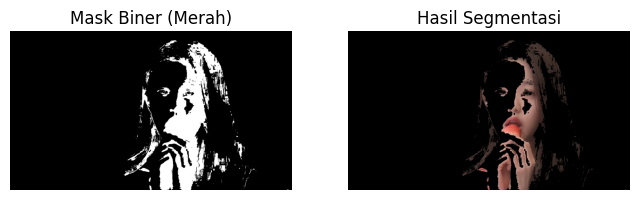

In [15]:
def hsv_color_masking(bgr_img):
    """Segments red objects in HSV color space."""
    hsv = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2HSV)
    # Red wraps around 0 and 180 degrees in HSV
    lower_red1 = np.array([0, 70, 50])
    upper_red1 = np.array([10, 255, 255])
    lower_red2 = np.array([170, 70, 50])
    upper_red2 = np.array([180, 255, 255])

    mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
    mask = cv2.bitwise_or(mask1, mask2)
    segmented = cv2.bitwise_or(bgr_img, bgr_img, mask=mask)
    return mask, segmented

mask, segmented = hsv_color_masking(img_bgr)
non_zero_pixels = np.count_nonzero(mask)
print(f"Piksel merah terdeteksi: {non_zero_pixels}")

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
axes[0].imshow(mask, cmap="gray")
axes[0].set_title("Mask Biner (Merah)")
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB))
axes[1].set_title("Hasil Segmentasi")
axes[1].axis("off")
plt.show()

## Tugas 2 (20 menit): Ekualisasi Histogram Manual dari Awal

### Langkah 3: Ekualisasi Histogram Manual NumPy / PyTorch
Diberikan citra grayscale $I$ dengan level intensitas $L = 256$:
1. Hitung frekuensi histogram $h(k) = \sum_{x,y} \mathbb{I}(I(x,y) = k)$ untuk $k \in [0, 255]$.
2. Hitung Cumulative Distribution Function (CDF): $CDF(k) = \sum_{j=0}^k \frac{h(j)}{N}$, dengan $N = H \times W$.
3. Petakan intensitas piksel baru: $T(k) = \text{round}\left(\frac{CDF(k) - CDF_{min}}{1 - CDF_{min}} \times 255\right)$.
4. Verifikasi hasil manual terhadap `cv2.equalizeHist()`.

MAE manual vs cv2.equalizeHist: 0.4940 (mendekati 0 = cocok)
[OK] Ekualisasi histogram manual terverifikasi.


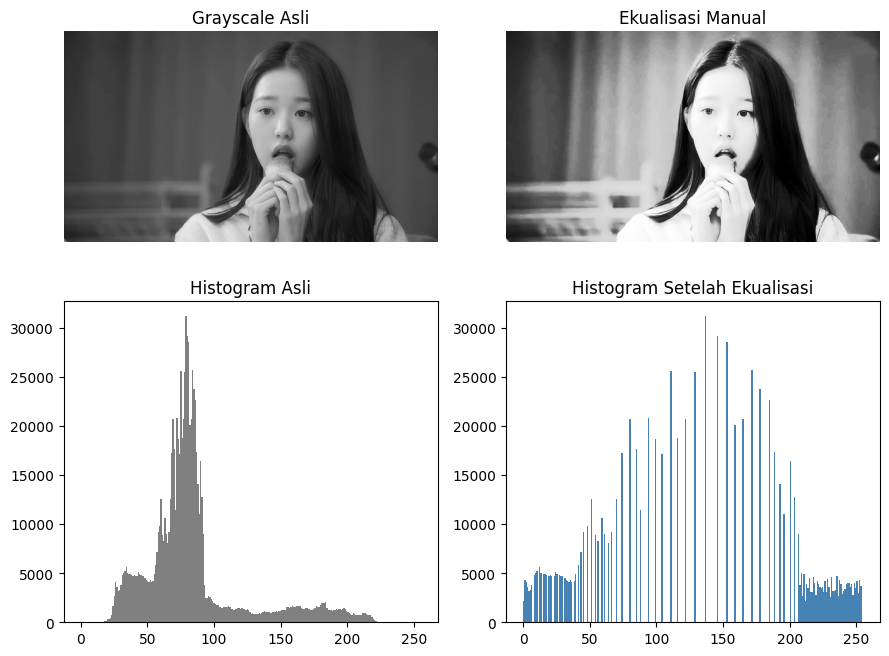

In [9]:
def manual_histogram_equalization(gray_img):
    """
    Computes histogram equalization from scratch using pure NumPy.
    Formula: T(k) = round((CDF(k) - CDF_min) / (N - CDF_min) * (L - 1))
    """
    # 1. Compute histogram
    hist = np.zeros(256, dtype=np.int32)
    for pixel in gray_img.flatten():
        hist[pixel] += 1

    # 2. Compute Cumulative Distribution Function (CDF)
    cdf = hist.cumsum()
    cdf_masked = np.ma.masked_equal(cdf, 0)

    # 3. Apply CDF equalization formula
    cdf_min = cdf_masked.min()
    total_pixels = gray_img.shape[0] * gray_img.shape[1]

    lookup_table = ((cdf_masked - cdf_min) * 255 / (total_pixels - cdf_min)).astype(np.uint8)
    equalized_img = lookup_table[gray_img]

    return equalized_img

gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
manual_eq = manual_histogram_equalization(gray)
cv_eq = cv2.equalizeHist(gray)
mae_diff = np.mean(np.abs(manual_eq.astype(float) - cv_eq.astype(float)))
print(f"MAE manual vs cv2.equalizeHist: {mae_diff:.4f} (mendekati 0 = cocok)")
assert mae_diff < 1.0, "Manual histogram equalization verification failed!"
print("[OK] Ekualisasi histogram manual terverifikasi.")

fig, axes = plt.subplots(2, 2, figsize=(9, 7))
axes[0, 0].imshow(gray, cmap="gray")
axes[0, 0].set_title("Grayscale Asli")
axes[0, 0].axis("off")
axes[0, 1].imshow(manual_eq, cmap="gray")
axes[0, 1].set_title("Ekualisasi Manual")
axes[0, 1].axis("off")
axes[1, 0].hist(gray.flatten(), bins=256, range=(0, 255), color="gray")
axes[1, 0].set_title("Histogram Asli")
axes[1, 1].hist(manual_eq.flatten(), bins=256, range=(0, 255), color="steelblue")
axes[1, 1].set_title("Histogram Setelah Ekualisasi")
plt.tight_layout()
plt.show()

## Tugas 3 (15 menit): Pipeline Pemuatan Batch Tensor & Normalisasi Standar ImageNet

### Langkah 4: Pipeline Normalisasi Batch Tensor
Bangun fungsi yang menerima batch tensor berukuran `(B, 3, H, W)` bernilai $[0, 1]$ dan menerapkan normalisasi ImageNet:
$$\mu = [0.485, 0.456, 0.406], \quad \sigma = [0.229, 0.224, 0.225]$$
$$X_{norm} = \frac{X - \mu}{\sigma}$$

In [21]:
def pytorch_batch_normalize(bgr_images_list):
    """
    Converts list of BGR numpy images (H, W, C) into normalized PyTorch batch tensor (B, C, H, W).
    """
    tensor_list = []
    for img_bgr_ in bgr_images_list:
        img_rgb_ = cv2.cvtColor(img_bgr_, cv2.COLOR_BGR2RGB)
        # HWC uint8 -> CHW float32 [0.0, 1.0]
        tensor = torch.from_numpy(img_rgb_).permute(2, 0, 1).float() / 255.0
        tensor_list.append(tensor)

    batch_tensor = torch.stack(tensor_list, dim=0)  # (B, 3, H, W)

    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
    normalized_batch = (batch_tensor - mean) / std

    return normalized_batch

h, w = img_bgr.shape[:2]
batch_norm = pytorch_batch_normalize([img_bgr, img_bgr])
print(f"PyTorch Batch Tensor shape: {batch_norm.shape} (B, C, H, W)")
print(f"Channel 0 (Red) Mean: {batch_norm[:, 0].mean().item():.4f}, Std: {batch_norm[:, 0].std().item():.4f}")
assert batch_norm.shape == (2, 3, h, w), "Batch dimension mismatch!"
print("[OK] Batch tensor shape terverifikasi.")

PyTorch Batch Tensor shape: torch.Size([2, 3, 720, 1280]) (B, C, H, W)
Channel 0 (Red) Mean: -0.5678, Std: 0.7533
[OK] Batch tensor shape terverifikasi.


## Verifikasi Akhir
Ringkasan semua pengecekan

In [22]:
print("[RUN] Praktikum 01: Tensors, Color Spaces & Histograms")
print(f"1. Citra dimuat, shape (H, W, C): {img_bgr.shape}, dtype: {img_bgr.dtype}")
print(f"2. HSV Red Color Masking selesai. Piksel merah terdeteksi: {non_zero_pixels}")
print(f"3. Ekualisasi Histogram Manual MAE vs OpenCV: {mae_diff:.4f}")
print(f"4. PyTorch Batch Tensor shape: {batch_norm.shape}")
print("\n[SUCCESS] Semua tugas Praktikum 01 berhasil diverifikasi!")

[RUN] Praktikum 01: Tensors, Color Spaces & Histograms
1. Citra dimuat, shape (H, W, C): (720, 1280, 3), dtype: uint8
2. HSV Red Color Masking selesai. Piksel merah terdeteksi: 624266
3. Ekualisasi Histogram Manual MAE vs OpenCV: 0.4940
4. PyTorch Batch Tensor shape: torch.Size([2, 3, 720, 1280])

[SUCCESS] Semua tugas Praktikum 01 berhasil diverifikasi!
